# Objective:
## Understand how different customer segments respond to price changes for a product

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import kruskal,levene,chi2_contingency,shapiro,norm


## Data generation

In [ ]:

np.random.seed(42)

# Parameters
n_users = 5000
segments = ['New', 'Returning', 'Loyal']
price_groups = ['Low', 'Medium', 'High']

# Conversion base rates by segment and price group (tuned for realism)
conversion_matrix = {
    'New': {'Low': 0.10, 'Medium': 0.07, 'High': 0.04},
    'Returning': {'Low': 0.15, 'Medium': 0.11, 'High': 0.08},
    'Loyal': {'Low': 0.25, 'Medium': 0.20, 'High': 0.15}
}

# Generate users
user_ids = np.arange(1, n_users + 1)

# Randomly assign segments and price groups
segments_sample = np.random.choice(segments, size=n_users, p=[0.4, 0.4, 0.2])
price_groups_sample = np.random.choice(price_groups, size=n_users, p=[0.3, 0.4, 0.3])

# Simulate conversions based on segment and price
conversions = []
for seg, price in zip(segments_sample, price_groups_sample):
    p = conversion_matrix[seg][price]
    conversions.append(np.random.binomial(1, p))

# Optional: simulate purchase amount (only if converted)
purchase_amount = [
    np.random.normal(loc=40 if price == 'Low' else 60 if price == 'Medium' else 80, scale=10)
    if conv == 1 else 0
    for conv, price in zip(conversions, price_groups_sample)
]

# Assemble DataFrame
df = pd.DataFrame({
    'user_id': user_ids,
    'segment': segments_sample,
    'price_group': price_groups_sample,
    'converted': conversions,
    'purchase_amount': np.round(purchase_amount, 2)
})

# Preview
print(df.head())


   user_id    segment price_group  converted  purchase_amount
0        1        New      Medium          0              0.0
1        2      Loyal      Medium          0              0.0
2        3  Returning        High          0              0.0
3        4  Returning      Medium          0              0.0
4        5        New        High          0              0.0


## Segment wise summary

In [ ]:
# Mean and median conversion rate by segment
segment_summary = df.groupby('segment')['converted'].agg(['mean', 'median', 'count']).rename(columns={
    'mean': 'conversion_rate_mean',
    'median': 'conversion_rate_median',
    'count': 'user_count'
})
print("Segment-wise Conversion Summary:")
print(segment_summary)


Segment-wise Conversion Summary:
           conversion_rate_mean  conversion_rate_median  user_count
segment                                                            
Loyal                  0.200200                     0.0         999
New                    0.077718                     0.0        2033
Returning              0.115346                     0.0        1968


## Price group wise summary

In [ ]:
# Mean and median conversion by price group
price_summary = df.groupby('price_group')['converted'].agg(['mean', 'median', 'count']).rename(columns={
    'mean': 'conversion_rate_mean',
    'median': 'conversion_rate_median',
    'count': 'user_count'
})
print("\nPrice Group-wise Conversion Summary:")
print(price_summary)



Price Group-wise Conversion Summary:
             conversion_rate_mean  conversion_rate_median  user_count
price_group                                                          
High                     0.073394                     0.0        1417
Low                      0.164915                     0.0        1522
Medium                   0.111596                     0.0        2061


## Segment × Price Group Conversion Heatmap

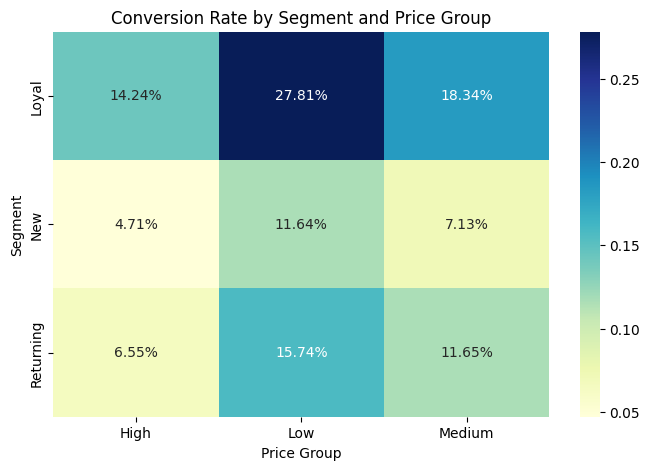

In [ ]:
pivot = pd.crosstab(index=df['segment'], columns=df['price_group'], values=df['converted'], aggfunc='mean')


plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="YlGnBu")
plt.title("Conversion Rate by Segment and Price Group")
plt.ylabel("Segment")
plt.xlabel("Price Group")
plt.show()


## Conversion Rate per Segment

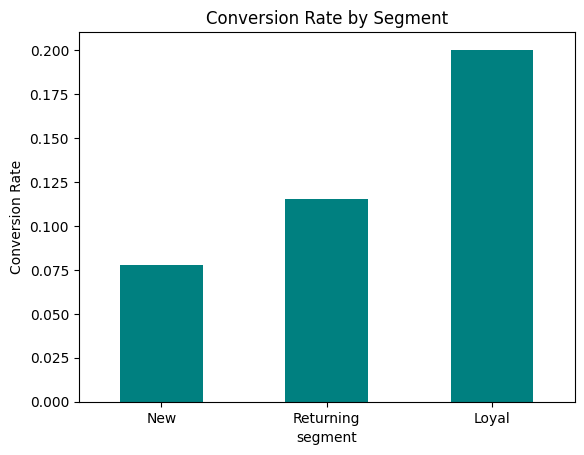

In [ ]:
segment_rates = df.groupby('segment')['converted'].mean().sort_values()
segment_rates.plot(kind='bar', color='teal', title='Conversion Rate by Segment')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()


## Purchase Amount by Price Group (Converted Users Only)

<ipython-input-28-6115f6089b98>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['converted'] == 1], x='price_group', y='purchase_amount', palette="Set2")


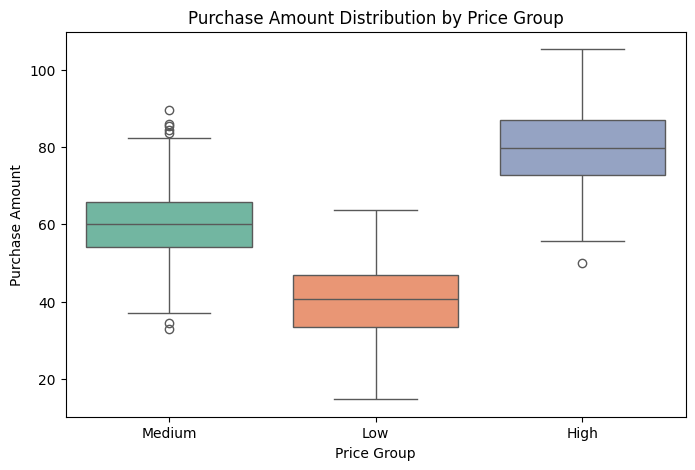

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['converted'] == 1], x='price_group', y='purchase_amount', palette="Set2")
plt.title("Purchase Amount Distribution by Price Group")
plt.xlabel("Price Group")
plt.ylabel("Purchase Amount")
plt.show()


## Independence test Segment vs. Conversion

In [ ]:


# Create contingency table
segment_conversion = pd.crosstab(df['segment'], df['converted'])

# Perform Chi-Square test
chi2_seg, p_seg, dof_seg, expected_seg = chi2_contingency(segment_conversion)

print("Chi-Square Test: Segment vs Converted")
print(f"Chi2 Statistic: {chi2_seg:.4f}")
print(f"p-value: {p_seg:.4f}")
print(f"Degrees of Freedom: {dof_seg}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected_seg, index=segment_conversion.index, columns=segment_conversion.columns))

if p_seg < 0.05:
    print("✅ There is a significant relationship between segment and conversion.")
else:
    print("❌ No significant relationship between segment and conversion.")


Chi-Square Test: Segment vs Converted
Chi2 Statistic: 97.3552
p-value: 0.0000
Degrees of Freedom: 2

Expected Frequencies:
converted         0        1
segment                     
Loyal       882.117  116.883
New        1795.139  237.861
Returning  1737.744  230.256
✅ There is a significant relationship between segment and conversion.


## Independence test Price Group vs. Conversion

In [ ]:
# Create contingency table
price_conversion = pd.crosstab(df['price_group'], df['converted'])

# Perform Chi-Square test
chi2_price, p_price, dof_price, expected_price = chi2_contingency(price_conversion)

print("\nChi-Square Test: Price Group vs Converted")
print(f"Chi2 Statistic: {chi2_price:.4f}")
print(f"p-value: {p_price:.4f}")
print(f"Degrees of Freedom: {dof_price}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected_price, index=price_conversion.index, columns=price_conversion.columns))

if p_price < 0.05:
    print("✅ There is a significant relationship between price group and conversion.")
else:
    print("❌ No significant relationship between price group and conversion.")



Chi-Square Test: Price Group vs Converted
Chi2 Statistic: 60.4848
p-value: 0.0000
Degrees of Freedom: 2

Expected Frequencies:
converted           0        1
price_group                   
High         1251.211  165.789
Low          1343.926  178.074
Medium       1819.863  241.137
✅ There is a significant relationship between price group and conversion.


## QQ Plot

Shapiro-Wilk for High: W=0.2850, p=0.0000
   ❌ Not normal
Shapiro-Wilk for Low: W=0.4471, p=0.0000
   ❌ Not normal
Shapiro-Wilk for Medium: W=0.3640, p=0.0000
   ❌ Not normal


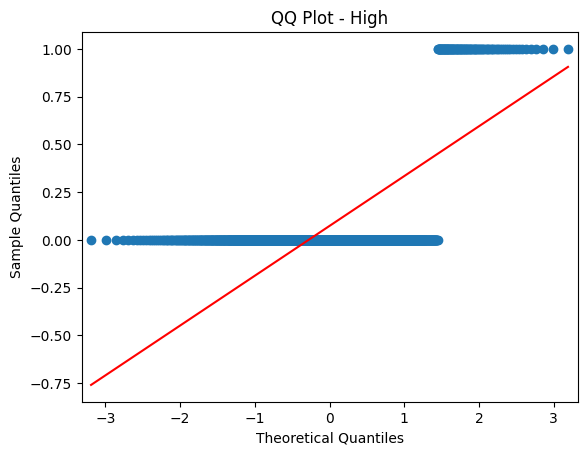

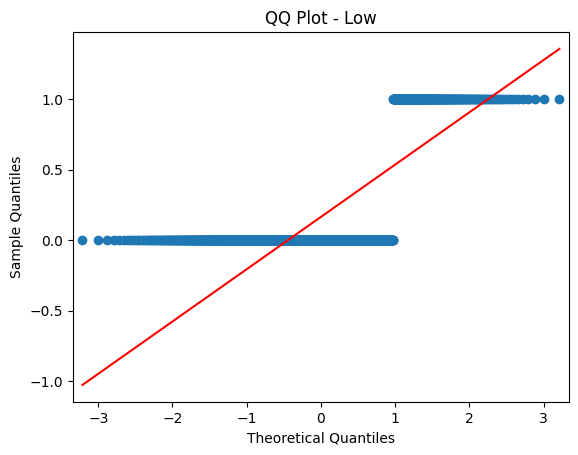

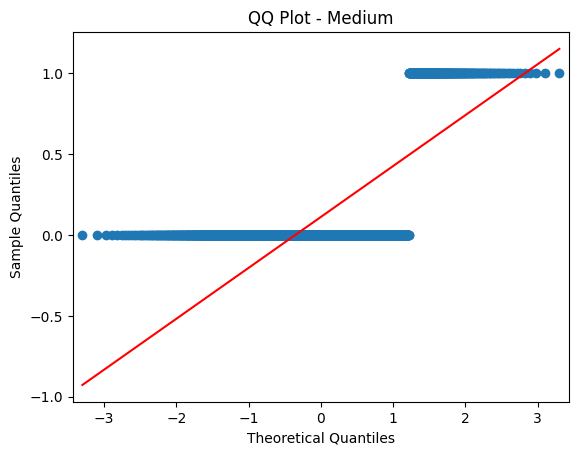

In [ ]:


# Shapiro-Wilk test for normality
for group_name, group_df in df.groupby('price_group'):
    stat, p = shapiro(group_df['converted'])
    print(f"Shapiro-Wilk for {group_name}: W={stat:.4f}, p={p:.4f}")
    if p > 0.05:
        print("   ✅ Likely normal")
    else:
        print("   ❌ Not normal")

# Optional: QQ Plots
for group_name, group_df in df.groupby('price_group'):
    sm.qqplot(group_df['converted'], line='s')
    plt.title(f"QQ Plot - {group_name}")
    plt.show()


## Homogeneity of Variances (Levene’s Test)

In [ ]:

low = df[df['price_group'] == 'Low']['converted']
med = df[df['price_group'] == 'Medium']['converted']
high = df[df['price_group'] == 'High']['converted']

stat, p = levene(low, med, high)
print(f"Levene's Test: W={stat:.4f}, p={p:.4f}")

if p > 0.05:
    print("✅ Equal variances assumed (OK for ANOVA)")
else:
    print("❌ Variances differ (use Welch’s ANOVA or Kruskal-Wallis)")


Levene's Test: W=30.5943, p=0.0000
❌ Variances differ (use Welch’s ANOVA or Kruskal-Wallis)


# Kruskal-Wallis Test (Non-Parametric)

In [ ]:

# Perform Kruskal-Wallis test
grouped = [group['purchase_amount'].values for _, group in df.groupby('price_group')]

h_stat, p_kw = kruskal(*grouped)

print("\nKruskal-Wallis Test (Non-Parametric):")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_kw:.4f}")

if p_kw < 0.05:
    print("✅ Significant difference (non-parametric) between price groups.")
else:
    print("❌ No significant difference (non-parametric).")



Kruskal-Wallis Test (Non-Parametric):
H-statistic: 40.1594
p-value: 0.0000
✅ Significant difference (non-parametric) between price groups.


<ipython-input-41-d8508a3de0ed>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = [group['purchase_amount'].values for _, group in df.groupby('price_group')]


In [ ]:

# Perform Kruskal-Wallis test
grouped = [group['purchase_amount'].values for _, group in df.groupby('segment')]

h_stat, p_kw = kruskal(*grouped)

print("\nKruskal-Wallis Test (Non-Parametric):")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_kw:.4f}")

if p_kw < 0.05:
    print("✅ Significant difference (non-parametric) between user segments.")
else:
    print("❌ No significant difference (non-parametric).")



Kruskal-Wallis Test (Non-Parametric):
H-statistic: 97.6203
p-value: 0.0000
✅ Significant difference (non-parametric) between user segments.


## Effect Size

In [ ]:

# Group data for converted users
group_data = [group['purchase_amount'].values for _, group in df.groupby('price_group')]


# Kruskal-Wallis test
h_stat, p_val = kruskal(*group_data)

# Effect Size: Epsilon Squared
k = len(group_data)
n = sum(len(group) for group in group_data)
epsilon_sq = (h_stat - k + 1) / (n - k)

print(f"Kruskal-Wallis H: {h_stat:.4f}")
print(f"Epsilon Squared (ε²): {epsilon_sq:.4f}")

# Interpretation
if epsilon_sq < 0.01:
    interpretation = "Negligible effect"
elif epsilon_sq < 0.08:
    interpretation = "Small effect"
elif epsilon_sq < 0.26:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"

print(f"Effect Size Interpretation: {interpretation}")


Kruskal-Wallis H: 40.1594
Epsilon Squared (ε²): 0.0076
Effect Size Interpretation: Negligible effect


<ipython-input-44-34b595b3fcb9>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_data = [group['purchase_amount'].values for _, group in df.groupby('price_group')]


In [ ]:

# Group data for converted users
group_data = [group['purchase_amount'].values for _, group in df.groupby('segment')]


# Kruskal-Wallis test
h_stat, p_val = kruskal(*group_data)

# Effect Size: Epsilon Squared
k = len(group_data)
n = sum(len(group) for group in group_data)
epsilon_sq = (h_stat - k + 1) / (n - k)

print(f"Kruskal-Wallis H: {h_stat:.4f}")
print(f"Epsilon Squared (ε²): {epsilon_sq:.4f}")

# Interpretation
if epsilon_sq < 0.01:
    interpretation = "Negligible effect"
elif epsilon_sq < 0.08:
    interpretation = "Small effect"
elif epsilon_sq < 0.26:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"

print(f"Effect Size Interpretation: {interpretation}")


Kruskal-Wallis H: 97.6203
Epsilon Squared (ε²): 0.0191
Effect Size Interpretation: Small effect


## Confidence Interval

In [ ]:

# Group by segment (e.g., 'price_group') and calculate conversion rates
segment_summary = df.groupby('price_group').agg(
    conversions=('converted', 'sum'),
    total_users=('converted', 'count')
).reset_index()

# Calculate conversion rate and confidence interval for each segment
z = norm.ppf(0.975)  # 1.96 for 95% CI

segment_summary['conversion_rate'] = segment_summary['conversions'] / segment_summary['total_users']

# Standard error for proportion
segment_summary['se'] = np.sqrt(
    (segment_summary['conversion_rate'] * (1 - segment_summary['conversion_rate'])) / segment_summary['total_users']
)

# Confidence Interval
segment_summary['ci_lower'] = segment_summary['conversion_rate'] - z * segment_summary['se']
segment_summary['ci_upper'] = segment_summary['conversion_rate'] + z * segment_summary['se']

# Display results
print(segment_summary[['price_group', 'conversion_rate', 'ci_lower', 'ci_upper']])


  price_group  conversion_rate  ci_lower  ci_upper
0        High         0.073394  0.059816  0.086973
1         Low         0.164915  0.146271  0.183558
2      Medium         0.111596  0.098003  0.125190


In [ ]:


# Group by segment (e.g., 'price_group') and calculate conversion rates
segment_summary = df.groupby('segment').agg(
    conversions=('converted', 'sum'),
    total_users=('converted', 'count')
).reset_index()

# Calculate conversion rate and confidence interval for each segment
z = norm.ppf(0.975)  # 1.96 for 95% CI

segment_summary['conversion_rate'] = segment_summary['conversions'] / segment_summary['total_users']

# Standard error for proportion
segment_summary['se'] = np.sqrt(
    (segment_summary['conversion_rate'] * (1 - segment_summary['conversion_rate'])) / segment_summary['total_users']
)

# Confidence Interval
segment_summary['ci_lower'] = segment_summary['conversion_rate'] - z * segment_summary['se']
segment_summary['ci_upper'] = segment_summary['conversion_rate'] + z * segment_summary['se']

# Display results
print(segment_summary[['segment', 'conversion_rate', 'ci_lower', 'ci_upper']])


     segment  conversion_rate  ci_lower  ci_upper
0      Loyal         0.200200  0.175387  0.225014
1        New         0.077718  0.066080  0.089355
2  Returning         0.115346  0.101232  0.129459


## Sensitivity visualization

<ipython-input-38-c5b03ce9c2a8>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['segment', 'price_group'])['converted'].mean().reset_index()


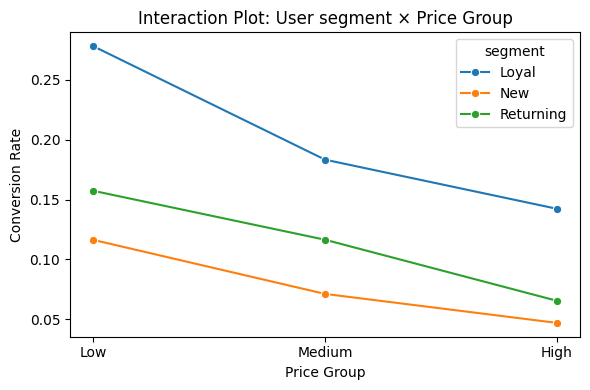

In [ ]:

# Ensure correct order for price groups
price_order = ['Low', 'Medium', 'High']
df['price_group'] = pd.Categorical(df['price_group'], categories=price_order, ordered=True)

# Calculate mean conversion rate for each combination
grouped = df.groupby(['segment', 'price_group'])['converted'].mean().reset_index()

# Plot the interaction
plt.figure(figsize=(6, 4))
sns.lineplot(data=grouped, x='price_group', y='converted', hue='segment', marker='o')
plt.title("Interaction Plot: User segment × Price Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Price Group")
plt.tight_layout()
plt.show()


# Summary

1. Lower prices increase the likelihood of users converting irrespective of customer segment
2. Loyal Users have highest conversion rates at all price points but steepest decline in conversion from Low → High price, which indicates they are very price sensitive, even though they convert more overall
3. Returning users show moderate price sensitivity
4. New users are least sensitive to price. Their low conversion rate may be driven by lack of trust or familiarity more than cost.

5. Price Group(Negligible Effect Size) :
Although there may be statistically significant differences between price groups (especially with large sample sizes), the practical impact is negligible.

 Implication: Changing the price within tested ranges does not meaningfully influence customer behavior. You may not need to change pricing strategies based on this factor alone.

 Use Case: Consider investing resources elsewhere (e.g., personalization or promotions) instead of price tweaking.

6. Segment (Small Effect Size)
The difference in behavior across segments is small but not trivial.

 Implication: Segment-specific behavior exists and could be exploited via targeted marketing or customized user experiences.

 Use Case: For example, younger users might respond better to discounts, while repeat buyers may prefer loyalty points—a segmentation strategy could yield ROI.



## Business decisions

1. Don't rely on price changes alone : Price has negligible impact overall; focus efforts elsewhere.

2. Target users by segment : Segment behavior differs slightly and can be used for personalized marketing.

3. Loyal users need careful pricing : They convert well but are price sensitive; use loyalty discounts or perks.

4. Returning users : Show moderate price sensitivity; test moderate offers like free shipping.

5. New users : Not price-sensitive but low trust; focus on trust-building (e.g., reviews, guarantees).

6. Invest in personalization and user experience : More effective than tweaking prices.